<a href="https://colab.research.google.com/github/Winskiii/Road-Safety/blob/main/Copy_of_FPML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [ ]:
#Cek missing values

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()


status                                2356
collision_year                        2388
collision_reference                   2306
sex_of_casualty                       2330
pedestrian_road_maintenance_worker    2335
casualty_home_area_type               2357
dtype: int64


,0
status,2356
collision_index,0
collision_year,2388
collision_reference,2306
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,2330
age_of_casualty,0
age_band_of_casualty,0


In [ ]:
df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty"], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

Series([], dtype: int64)


<ipython-input-5-3785775902>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
<ipython-input-5-3785775902>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
collision_index,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
age_band_of_casualty,0
pedestrian_location,0
pedestrian_movement,0
car_passenger,0


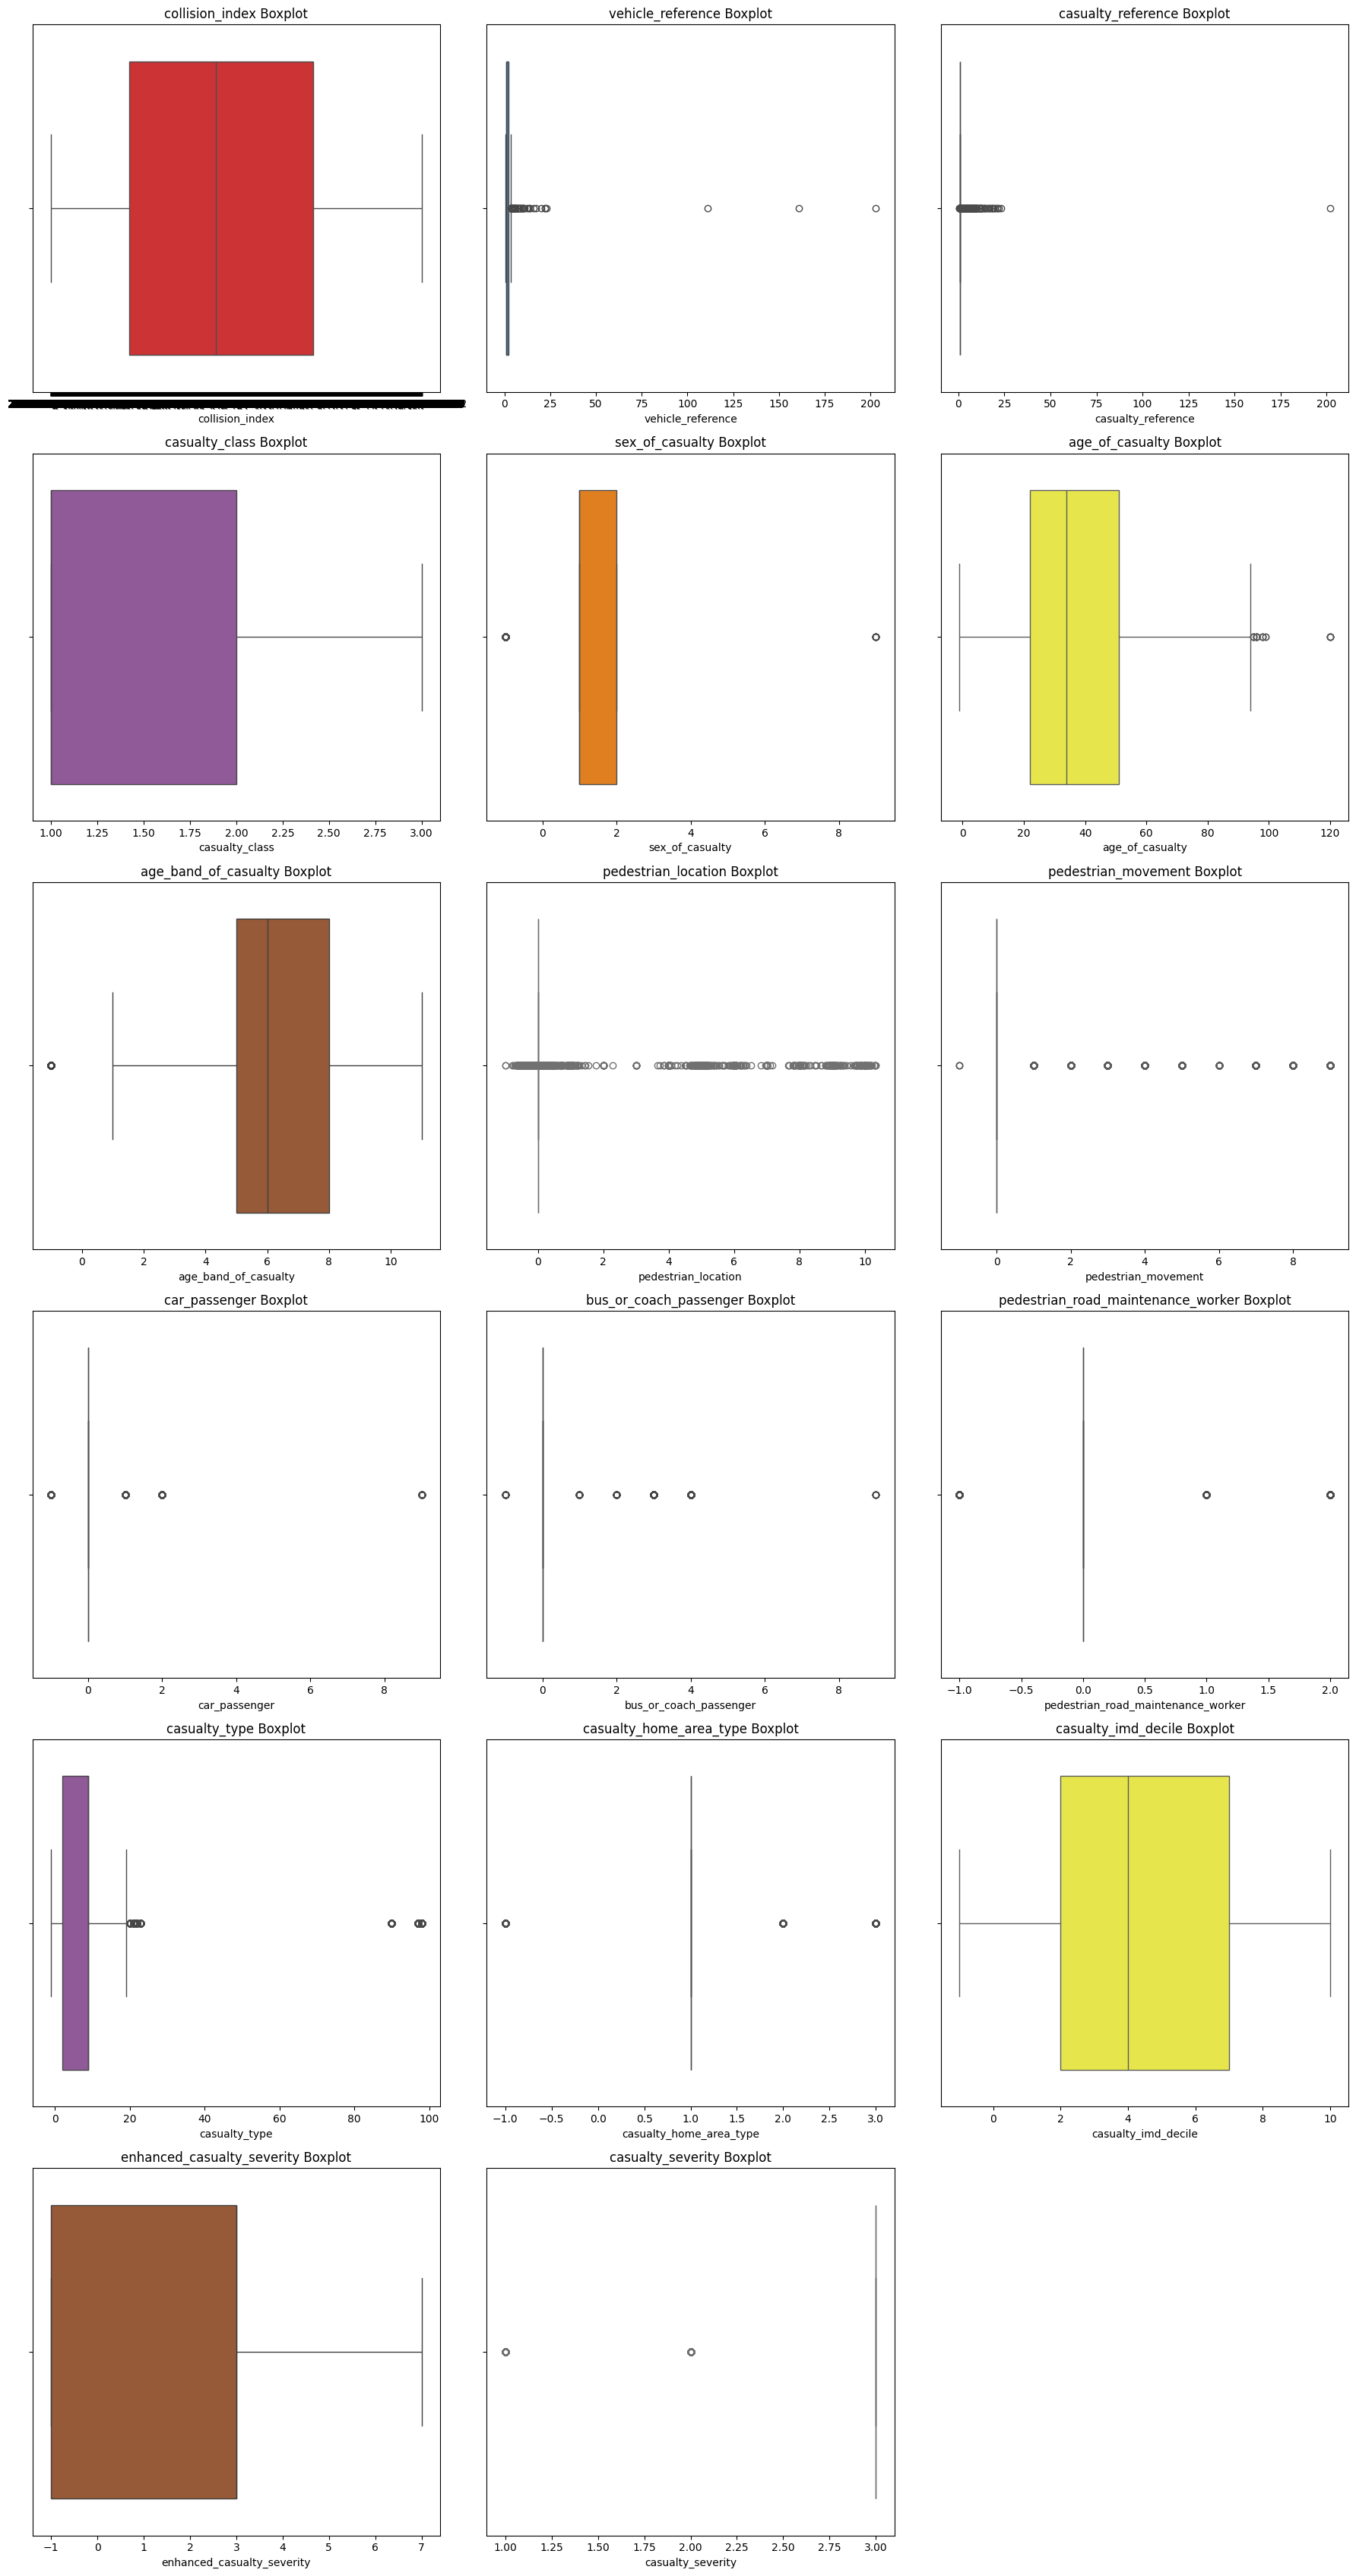

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

col_box = [
    'collision_index', 'vehicle_reference', 'casualty_reference',
    'casualty_class', 'sex_of_casualty', 'age_of_casualty',
    'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
    'car_passenger', 'bus_or_coach_passenger',
    'pedestrian_road_maintenance_worker', 'casualty_type',
    'casualty_home_area_type', 'casualty_imd_decile',
    'enhanced_casualty_severity', 'casualty_severity'
]

color_palette = sns.color_palette("Set1", len(col_box))

plt.figure(figsize=(18, len(col_box) * 2))

for i, column in enumerate(col_box, 1):
    plt.subplot((len(col_box) // 3) + 1, 3, i)
    sns.boxplot(data=df, x=column, color=color_palette[i - 1])
    plt.xlabel(column)
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()


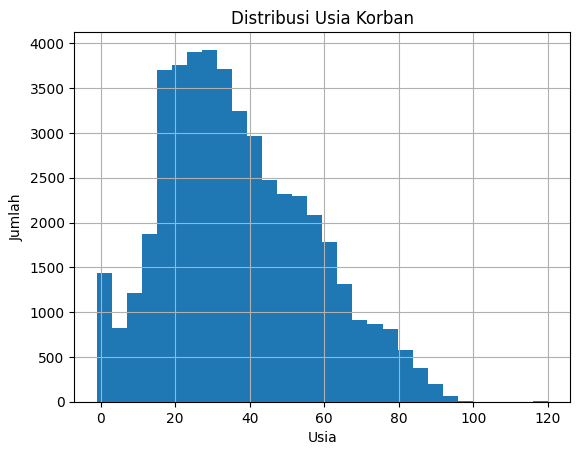

In [ ]:
df['age_of_casualty'].hist(bins=30)
plt.title("Distribusi Usia Korban")
plt.xlabel("Usia")
plt.ylabel("Jumlah")
plt.show()


In [ ]:
!pip install optuna

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import optuna

# Salin data
train = df.copy()

# Fitur dan target
X = train.drop(['casualty_severity'], axis=1)
y = train['casualty_severity'] - 1
print("Fitur yang digunakan:\n", X.columns.tolist())

# Label encoding untuk kategorikal
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=random_state)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Model-model
classifiers = [
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("XGBoost", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ("AdaBoost", AdaBoostClassifier(random_state=random_state)),
    ("GradientBoost", GradientBoostingClassifier(random_state=random_state)),
    ("Bagging", BaggingClassifier(random_state=random_state)),
]

# Tambahkan VotingClassifier (gabungan 3 terbaik)
voting = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(random_state=random_state)),
    ('xgb', XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ('gb', GradientBoostingClassifier(random_state=random_state))
], voting='soft')

classifiers.append(("Voting", voting))

# Cross-validation
cv_results = []
for name, model in classifiers:
    scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=kfold, n_jobs=-1)
    cv_results.append((name, scores.mean(), scores.std()))

# Hasil sebagai DataFrame
cv_res = pd.DataFrame(cv_results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
cv_res = cv_res.sort_values(by='CrossValMeans', ascending=False)

# Tampilkan hasil
print(cv_res)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 24.2 MB/s eta 0:00:00
Fitur yang digunakan:
 ['collision_index', 'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'enhanced_casualty_severity']
       Algorithm  CrossValMeans  CrossValStd
8         Voting       0.967979     0.000743
6  GradientBoost       0.967389     0.000701
4        XGBoost       0.966719     0.000898
3  Random Forest       0.966478     0.000840
7        Bagging       0.960583     0.000936
5       AdaBoost       0.956376     0.000952
2  Decision Tree       0.939548     0.001463
0            KNN       0.889065     0.001453
1     GaussianNB       0.847343     0.00488

In [ ]:
import optuna
from xgboost import XGBClassifier

def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss'
    }
    model = XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=30)
print("Best XGBoost params:", study_xgb.best_params)
print("Best XGBoost accuracy:", study_xgb.best_value)

[I 2025-06-11 01:13:58,933] A new study created in memory with name: no-name-114f0b05-34b2-4dd3-a777-dab5edb96bc2
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:13:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:14:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:14:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:14:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-package

Best XGBoost params: {'max_depth': 9, 'learning_rate': 0.2019239468850445, 'n_estimators': 146, 'subsample': 0.5107687442122053, 'colsample_bytree': 0.9508793289400967, 'gamma': 4.317688475733005, 'reg_alpha': 2.9539808336047484, 'reg_lambda': 4.6414565786610025}
Best XGBoost accuracy: 0.968380710325279


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    model = GradientBoostingClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=10)
print("Best GradientBoost params:", study_gb.best_params)
print("Best GradientBoost accuracy:", study_gb.best_value)


[I 2025-06-11 01:17:45,217] A new study created in memory with name: no-name-10c5d8c7-7b9d-491d-b9b2-4f54e2834fdc
[I 2025-06-11 01:18:04,181] Trial 0 finished with value: 0.9670141328876619 and parameters: {'n_estimators': 107, 'learning_rate': 0.09887780856700235, 'max_depth': 3, 'subsample': 0.7213142947561968, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9670141328876619.
[I 2025-06-11 01:18:29,948] Trial 1 finished with value: 0.967737612737307 and parameters: {'n_estimators': 95, 'learning_rate': 0.06571171205120296, 'max_depth': 5, 'subsample': 0.6892147794084975, 'max_features': 'log2'}. Best is trial 1 with value: 0.967737612737307.
[I 2025-06-11 01:19:18,855] Trial 2 finished with value: 0.9635306490224945 and parameters: {'n_estimators': 135, 'learning_rate': 0.24853276724498707, 'max_depth': 6, 'subsample': 0.7412201382298889, 'max_features': 'log2'}. Best is trial 1 with value: 0.967737612737307.
[I 2025-06-11 01:19:40,452] Trial 3 finished with value: 0.966129859

Best GradientBoost params: {'n_estimators': 95, 'learning_rate': 0.06571171205120296, 'max_depth': 5, 'subsample': 0.6892147794084975, 'max_features': 'log2'}
Best GradientBoost accuracy: 0.967737612737307


In [ ]:
from sklearn.ensemble import VotingClassifier

def objective_voting(trial):
    voting_type = trial.suggest_categorical("voting", ["hard", "soft"])

    clf1 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    clf2 = GradientBoostingClassifier(random_state=42)
    clf3 = RandomForestClassifier(random_state=42)

    model = VotingClassifier(estimators=[
        ('xgb', clf1),
        ('gb', clf2),
        ('rf', clf3)
    ], voting=voting_type)

    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

study_vote = optuna.create_study(direction='maximize')
study_vote.optimize(objective_voting, n_trials=10)
print("Best Voting params:", study_vote.best_params)
print("Best Voting accuracy:", study_vote.best_value)


[I 2025-06-11 01:32:13,860] A new study created in memory with name: no-name-c94bb6e7-360b-406d-8518-547de40b4509
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:32:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:32:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:32:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:32:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-package

Best Voting params: {'voting': 'soft'}
Best Voting accuracy: 0.9682199386210989


In [ ]:
print("=== Best XGBoost Hyperparameters ===")
print(study_xgb.best_params)
print("Best XGBoost Accuracy:", study_xgb.best_value)

print("\n=== Best GradientBoost Hyperparameters ===")
print(study_gb.best_params)
print("Best GradientBoost Accuracy:", study_gb.best_value)

print("\n=== Best Voting Hyperparameters ===")
print(study_vote.best_params)
print("Best Voting Accuracy:", study_vote.best_value)


=== Best XGBoost Hyperparameters ===
{'max_depth': 9, 'learning_rate': 0.2019239468850445, 'n_estimators': 146, 'subsample': 0.5107687442122053, 'colsample_bytree': 0.9508793289400967, 'gamma': 4.317688475733005, 'reg_alpha': 2.9539808336047484, 'reg_lambda': 4.6414565786610025}
Best XGBoost Accuracy: 0.968380710325279

=== Best GradientBoost Hyperparameters ===
{'n_estimators': 95, 'learning_rate': 0.06571171205120296, 'max_depth': 5, 'subsample': 0.6892147794084975, 'max_features': 'log2'}
Best GradientBoost Accuracy: 0.967737612737307

=== Best Voting Hyperparameters ===
{'voting': 'soft'}
Best Voting Accuracy: 0.9682199386210989


In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

best_xgb = XGBClassifier(
    max_depth=7,
    learning_rate=0.2359782567798041,
    n_estimators=169,
    subsample=0.9164284317895103,
    colsample_bytree=0.9870113967843601,
    gamma=2.104555451344951,
    reg_alpha=1.3445284724960733,
    reg_lambda=0.2139048652770632,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

best_gb = GradientBoostingClassifier(
    n_estimators=127,
    learning_rate=0.015539414363935633,
    max_depth=5,
    subsample=0.6013780101099223,
    max_features=None,
    random_state=42
)

voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('gb', best_gb),
        ('rf', RandomForestClassifier(random_state=42))
    ],
    voting='soft'
)

best_xgb.fit(X_train, y_train)
best_gb.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

xgb_acc = accuracy_score(y_test, best_xgb.predict(X_test))
gb_acc = accuracy_score(y_test, best_gb.predict(X_test))
voting_acc = accuracy_score(y_test, voting_clf.predict(X_test))

print(f"XGBoost Validation Accuracy: {xgb_acc:.5f}")
print(f"GradientBoost Validation Accuracy: {gb_acc:.5f}")
print(f"VotingClassifier Validation Accuracy: {voting_acc:.5f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:55:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:55:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Validation Accuracy: 0.96742
GradientBoost Validation Accuracy: 0.96752
VotingClassifier Validation Accuracy: 0.96742


<ipython-input-14-452913724>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


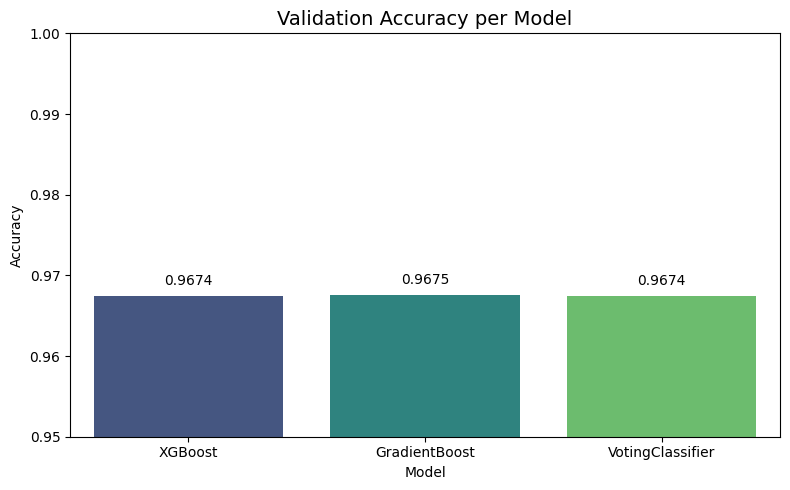

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data akurasi model
model_names = ['XGBoost', 'GradientBoost', 'VotingClassifier']
accuracies = [xgb_acc, gb_acc, voting_acc]

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette="viridis")
plt.ylim(0.95, 1.0)
plt.title("Validation Accuracy per Model", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.001, f"{acc:.4f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


<ipython-input-15-3495857204>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='casualty_severity', data=df, palette='viridis')


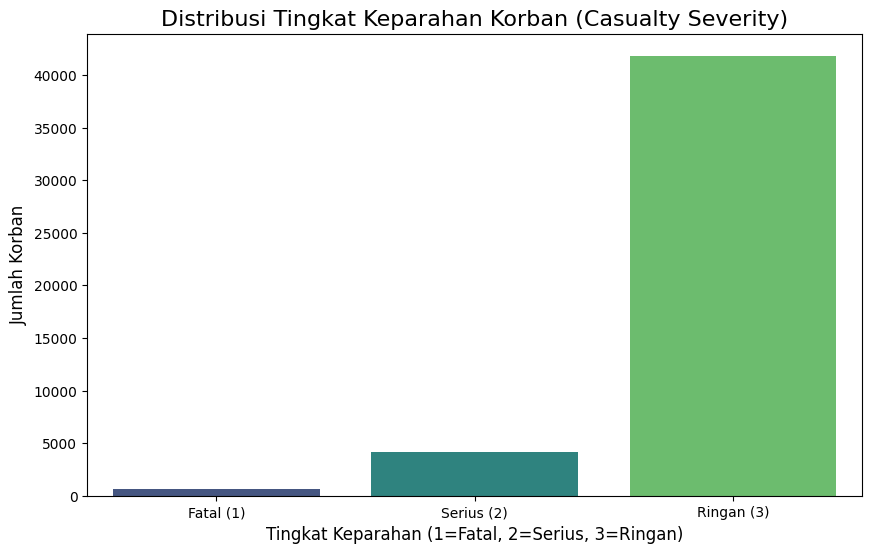

Jumlah korban per tingkat keparahan:
casualty_severity
3    41823
2     4182
1      644
Name: count, dtype: int64


In [ ]:
# SEL BARU 1: ANALISIS DISTRIBUSI VARIABEL TARGET

import seaborn as sns
import matplotlib.pyplot as plt

# Membuat plot untuk melihat distribusi kelas target
plt.figure(figsize=(10, 6))
sns.countplot(x='casualty_severity', data=df, palette='viridis')
plt.title('Distribusi Tingkat Keparahan Korban (Casualty Severity)', fontsize=16)
plt.xlabel('Tingkat Keparahan (1=Fatal, 2=Serius, 3=Ringan)', fontsize=12)
plt.ylabel('Jumlah Korban', fontsize=12)
plt.xticks([0, 1, 2], ['Fatal (1)', 'Serius (2)', 'Ringan (3)']) # Mengganti label sumbu-x
plt.show()

# Menampilkan jumlah pasti untuk setiap kelas
print("Jumlah korban per tingkat keparahan:")
print(df['casualty_severity'].value_counts())

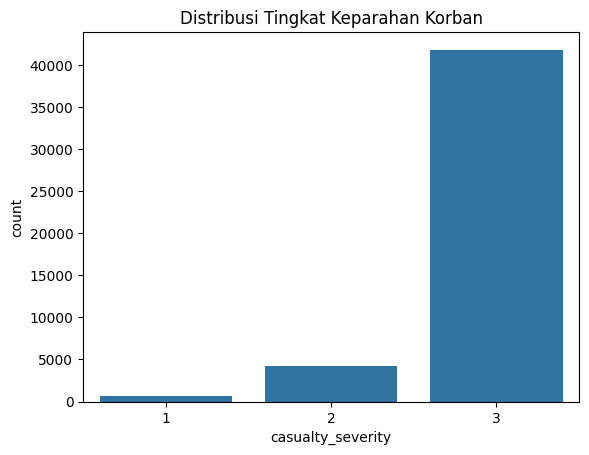

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='casualty_severity', data=df)
plt.title('Distribusi Tingkat Keparahan Korban')
plt.show()

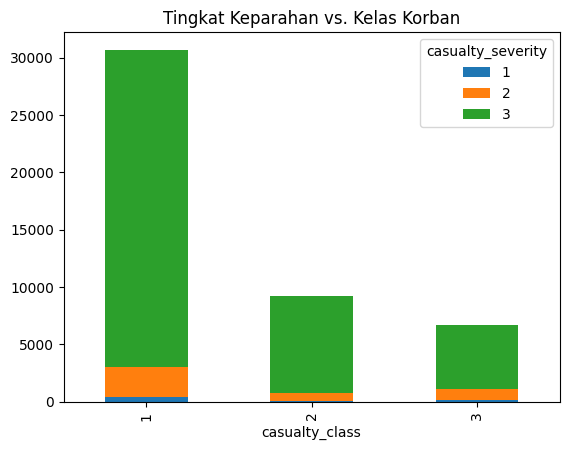

In [ ]:
pd.crosstab(df['casualty_class'], df['casualty_severity']).plot(kind='bar', stacked=True)
plt.title('Tingkat Keparahan vs. Kelas Korban')
plt.show()

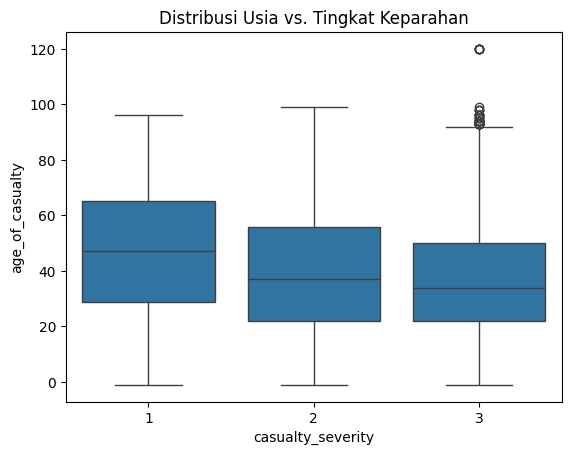

In [ ]:
sns.boxplot(x='casualty_severity', y='age_of_casualty', data=df)
plt.title('Distribusi Usia vs. Tingkat Keparahan')
plt.show()

Metrik Evaluasi yang Berbeda:

Akurasi bisa menyesatkan jika datanya tidak seimbang. Gunakan metrik lain yang lebih informatif seperti Precision, Recall, dan F1-Score (terutama f1_score dengan average='weighted' atau 'macro'). classification_report dari Scikit-learn akan memberikan semua ini.
Confusion Matrix: Visualisasikan confusion matrix untuk model terbaik Anda. Ini akan menunjukkan secara detail di kelas mana model Anda paling sering membuat kesalahan.


              precision    recall  f1-score   support

           0       1.00      0.75      0.86       129
           1       1.00      0.68      0.81       836
           2       0.97      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.99      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330



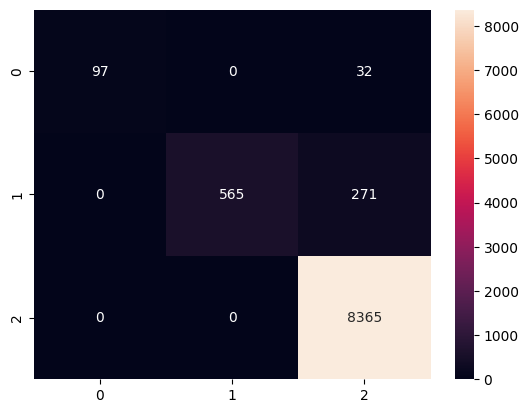

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_gb.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

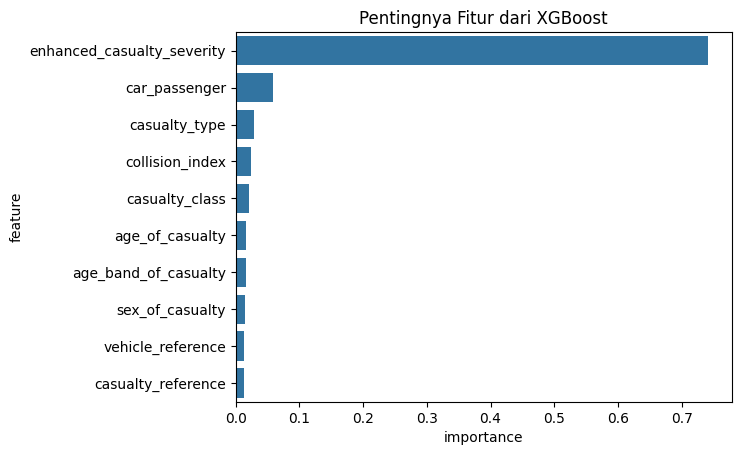

In [ ]:
importances = best_xgb.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feature_importance_df.head(10)) # Tampilkan 10 teratas
plt.title('Pentingnya Fitur dari XGBoost')
plt.show()

el Baru 2: Analisis Bivariat (Kategorikal vs. Target)
Sel ini akan membantu Anda memahami hubungan antara fitur kategorikal (contoh: casualty_class) dengan tingkat keparahan korban.

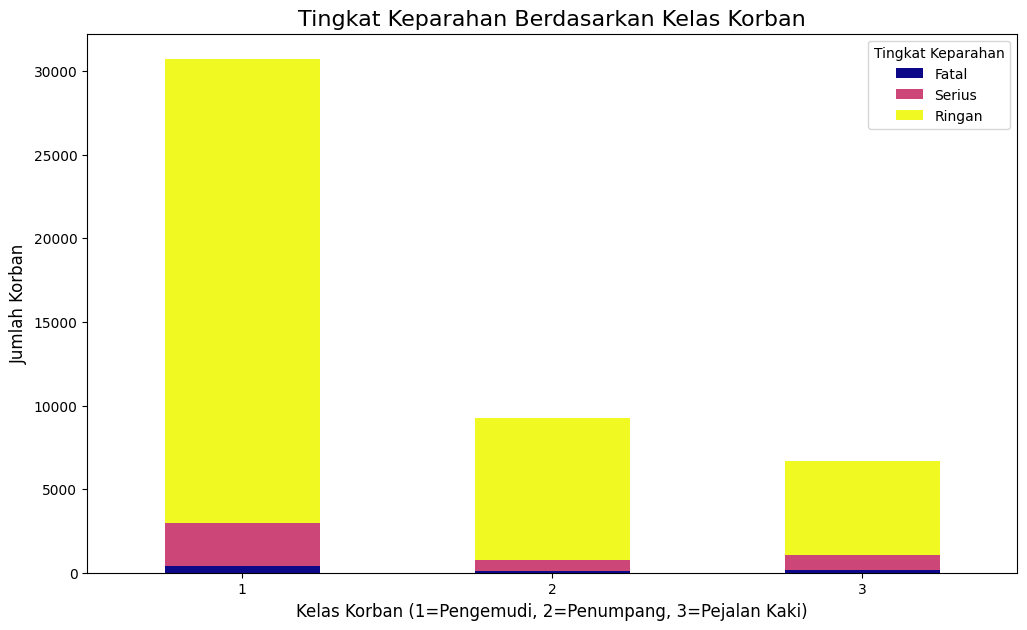

Tabel Silang Kelas Korban vs Tingkat Keparahan:
casualty_severity    1     2      3
casualty_class                     
1                  393  2602  27707
2                   83   666   8496
3                  168   914   5620


In [ ]:
# SEL BARU 2: ANALISIS BIVARIAT - KELAS KORBAN VS TINGKAT KEPARAHAN

# Membuat tabel silang untuk melihat hubungan antara kelas korban dan tingkat keparahan
crosstab_class = pd.crosstab(df['casualty_class'], df['casualty_severity'])

# Membuat stacked bar chart
crosstab_class.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma')
plt.title('Tingkat Keparahan Berdasarkan Kelas Korban', fontsize=16)
plt.xlabel('Kelas Korban (1=Pengemudi, 2=Penumpang, 3=Pejalan Kaki)', fontsize=12)
plt.ylabel('Jumlah Korban', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Tingkat Keparahan', labels=['Fatal', 'Serius', 'Ringan'])
plt.show()

print("Tabel Silang Kelas Korban vs Tingkat Keparahan:")
print(crosstab_class)

Sel Baru 3: Analisis Bivariat (Numerik vs. Target)
Sel ini membandingkan distribusi fitur numerik (contoh: age_of_casualty) untuk setiap kategori tingkat keparahan.

<ipython-input-24-1020726978>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='casualty_severity', y='age_of_casualty', data=df, palette='magma')


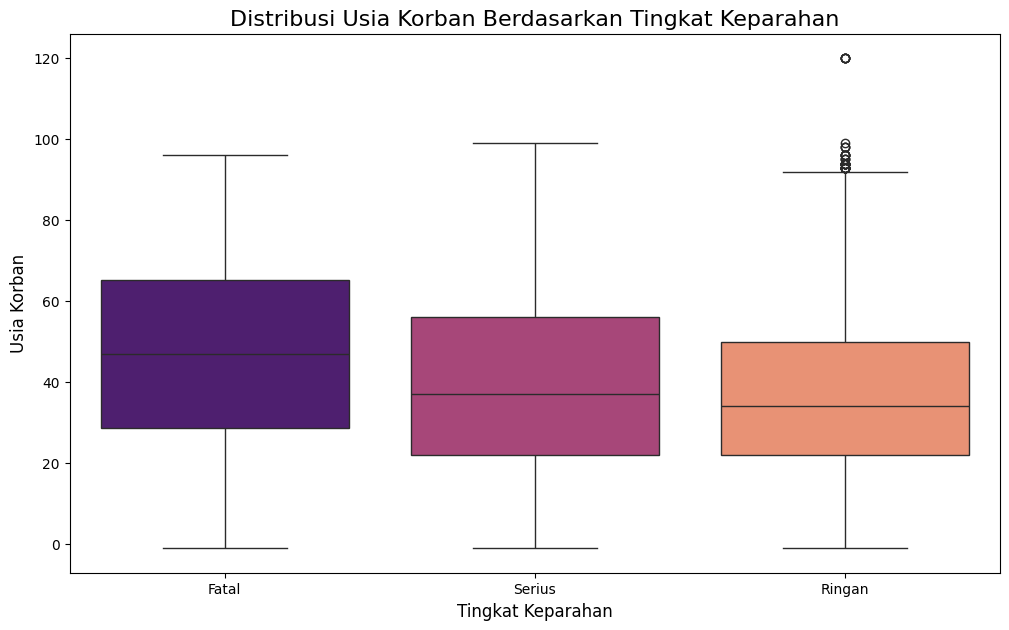

In [ ]:
# SEL BARU 3: ANALISIS BIVARIAT - USIA VS TINGKAT KEPARAHAN

plt.figure(figsize=(12, 7))
sns.boxplot(x='casualty_severity', y='age_of_casualty', data=df, palette='magma')
plt.title('Distribusi Usia Korban Berdasarkan Tingkat Keparahan', fontsize=16)
plt.xlabel('Tingkat Keparahan', fontsize=12)
plt.ylabel('Usia Korban', fontsize=12)
plt.xticks([0, 1, 2], ['Fatal', 'Serius', 'Ringan'])
plt.show()

Sel Baru 4: Heatmap Korelasi Fitur Numerik
Sel ini akan menunjukkan korelasi atau hubungan linear antara semua fitur numerik dalam dataset Anda.

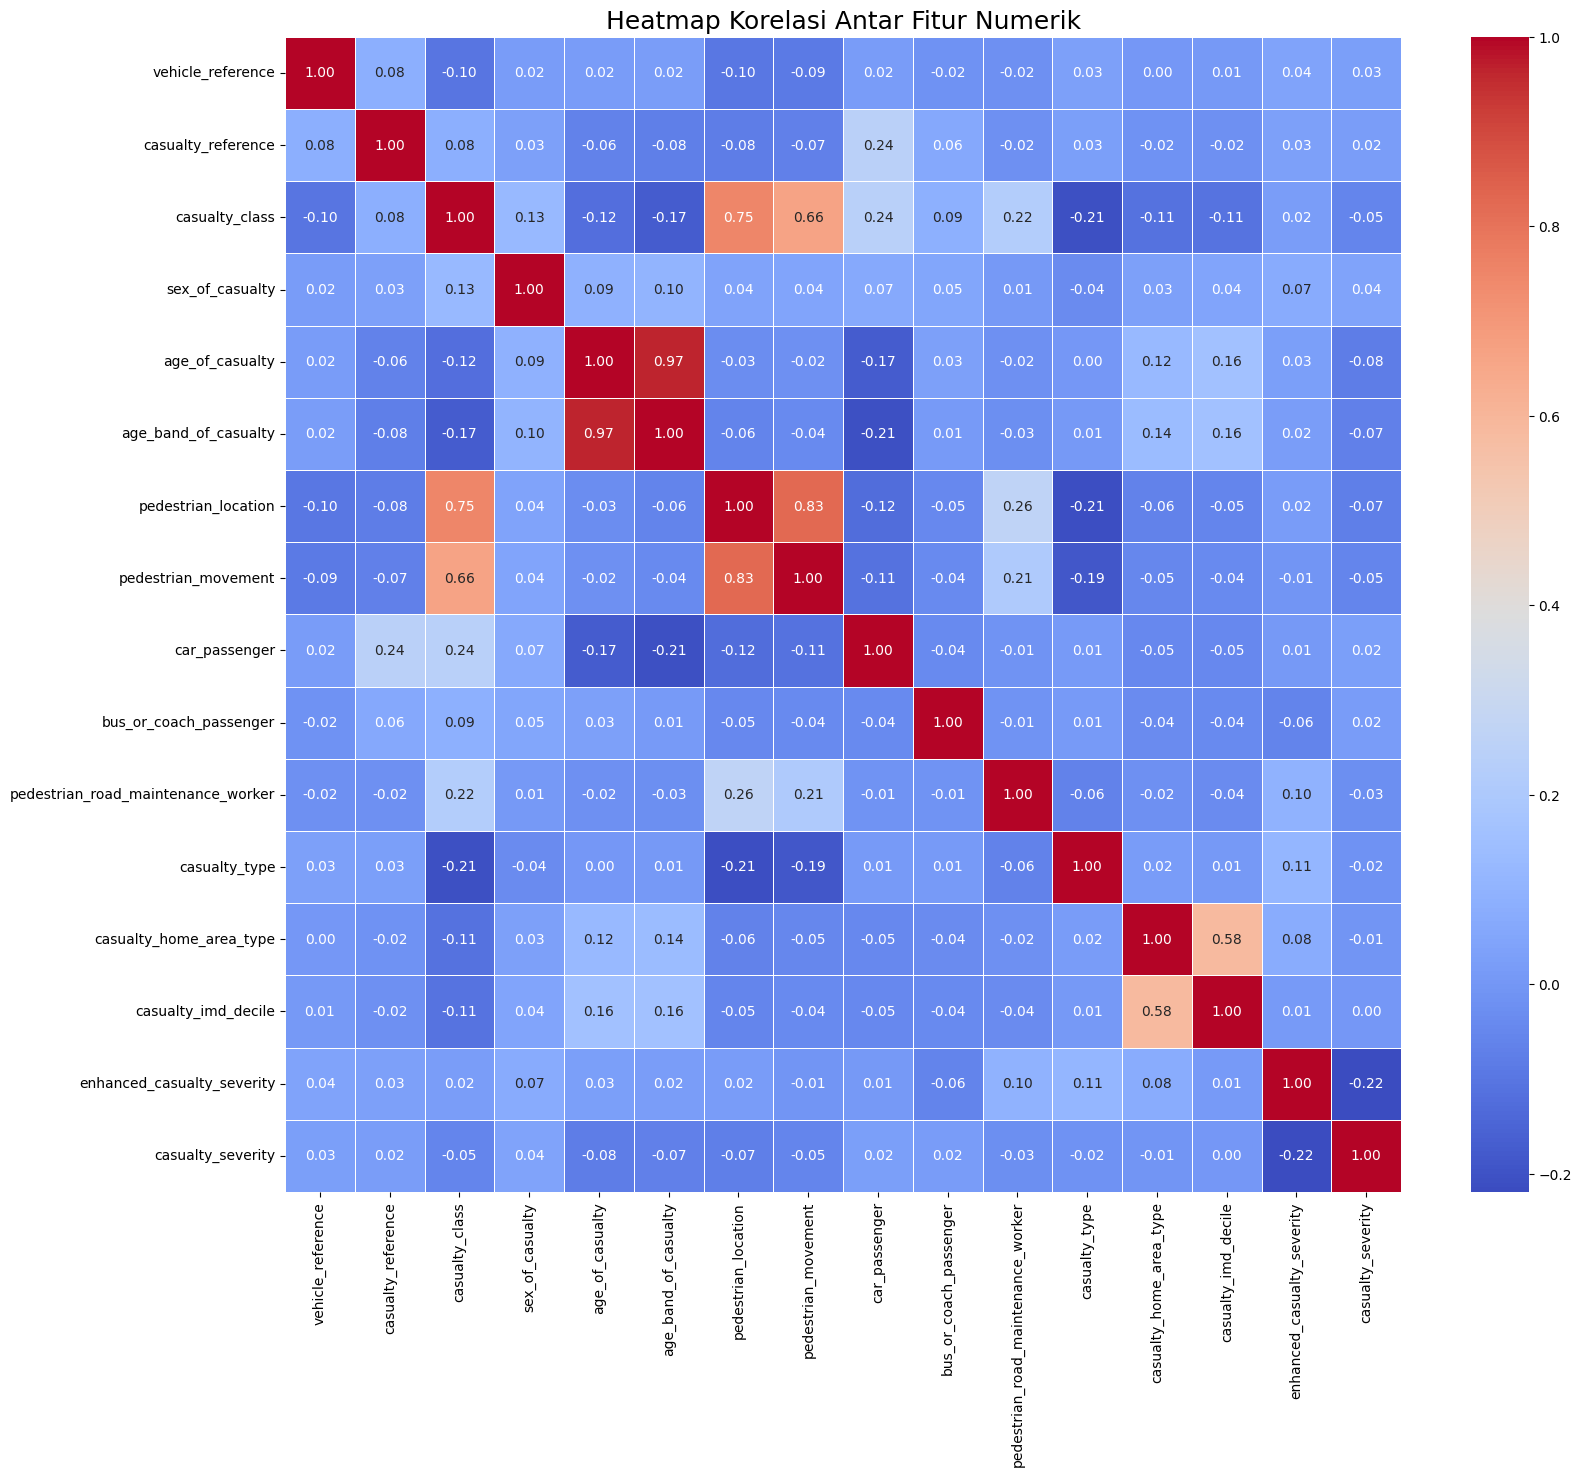

In [ ]:
# SEL BARU 4: HEATMAP KORELASI FITUR NUMERIK

# Menghitung matriks korelasi hanya untuk kolom numerik
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=18)
plt.show()

el Baru 5: Rekayasa Fitur (Feature Engineering)
Ini adalah sel yang sangat penting untuk menciptakan fitur baru yang dapat membantu model belajar lebih baik. Di sini kita akan membuat grup usia dan menerapkan penskalaan fitur.

In [ ]:
# SEL BARU 5: REKAYASA FITUR (FEATURE ENGINEERING)

from sklearn.preprocessing import StandardScaler

# Salin dataframe yang sudah bersih untuk rekayasa fitur
df_engineered = df.copy()

# 1. Membuat Kategori Usia
bins = [0, 12, 18, 25, 60, 120]
labels = ['Anak-anak', 'Remaja', 'Dewasa Muda', 'Dewasa', 'Lansia']
df_engineered['age_group'] = pd.cut(df_engineered['age_of_casualty'], bins=bins, labels=labels, right=False)

# 2. One-Hot Encoding untuk fitur kategorikal baru 'age_group'
# Ini mengubah kategori menjadi kolom biner, yang lebih baik untuk sebagian besar model
df_engineered = pd.get_dummies(df_engineered, columns=['age_group'], drop_first=True)

# 3. Penskalaan Fitur Numerik
# Ini penting untuk model seperti KNN dan dapat membantu beberapa model lain
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

# Buat salinan dari data fitur Anda untuk diskalakan
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Contoh data setelah Feature Scaling:")
print(X_scaled.head())

Contoh data setelah Feature Scaling:
   collision_index  vehicle_reference  casualty_reference  casualty_class  \
0        -0.707609          -0.315512           -0.279250        2.066450   
1        -1.259596          -0.315512           -0.279250       -0.662473   
2        -0.971330           0.376983           -0.279250        0.701989   
3        -0.071467          -0.315512           -0.279250        2.066450   
4        -1.600643          -0.315512            0.509818        0.701989   

   sex_of_casualty  age_of_casualty  age_band_of_casualty  \
0         1.146441        -1.921833             -2.937694   
1         1.146441         0.196557              0.270051   
2         1.146441        -1.165265             -1.333821   
3        -0.612780        -1.417455             -1.734789   
4         1.146441        -0.055632              0.270051   

   pedestrian_location  pedestrian_movement  car_passenger  \
0             1.458953             0.167296      -0.303640   
1        

Sel Baru 6: Evaluasi Model dengan Metrik Lanjutan
Setelah melatih model terbaik Anda (misalnya best_gb dari kode Anda sebelumnya), gunakan sel ini untuk mengevaluasinya dengan metrik yang lebih komprehensif.

Laporan Klasifikasi untuk VotingClassifier:
              precision    recall  f1-score   support

       Fatal       1.00      0.74      0.85       129
      Serius       1.00      0.68      0.81       836
      Ringan       0.96      1.00      0.98      8365

    accuracy                           0.97      9330
   macro avg       0.99      0.81      0.88      9330
weighted avg       0.97      0.97      0.96      9330


Confusion Matrix:


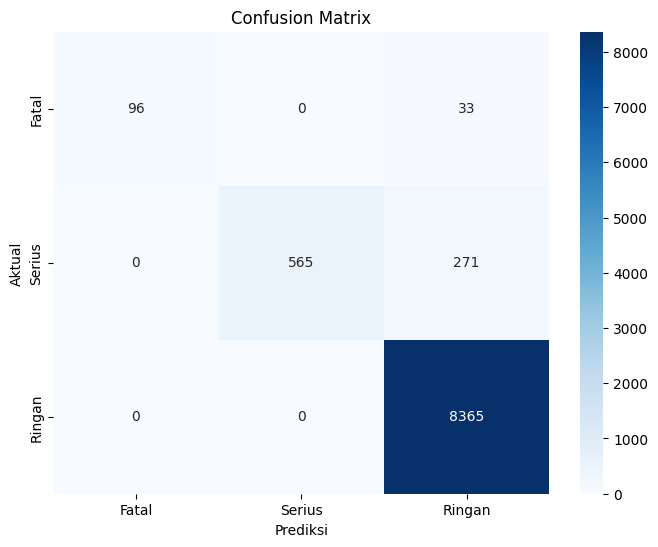

In [ ]:
# SEL BARU 6: EVALUASI MODEL DENGAN METRIK LANJUTAN

from sklearn.metrics import classification_report, confusion_matrix

# Pastikan model terbaik Anda (misal: voting_clf) sudah dilatih
# Jika belum, jalankan kembali sel pelatihan model Anda (sel kode [11])

# Membuat prediksi pada data uji
y_pred_final = voting_clf.predict(X_test)

# Menampilkan Classification Report (Precision, Recall, F1-Score)
# Label target (y) dikurangi 1, jadi 0=Fatal, 1=Serius, 2=Ringan
print("Laporan Klasifikasi untuk VotingClassifier:")
print(classification_report(y_test, y_pred_final, target_names=['Fatal', 'Serius', 'Ringan']))

# Menampilkan Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fatal', 'Serius', 'Ringan'], yticklabels=['Fatal', 'Serius', 'Ringan'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

Sel Baru 7: Analisis Pentingnya Fitur (Feature Importance)
Sel ini akan menunjukkan fitur mana yang paling dianggap penting oleh model terbaik Anda dalam membuat prediksi.

<ipython-input-28-1833440936>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='rocket')


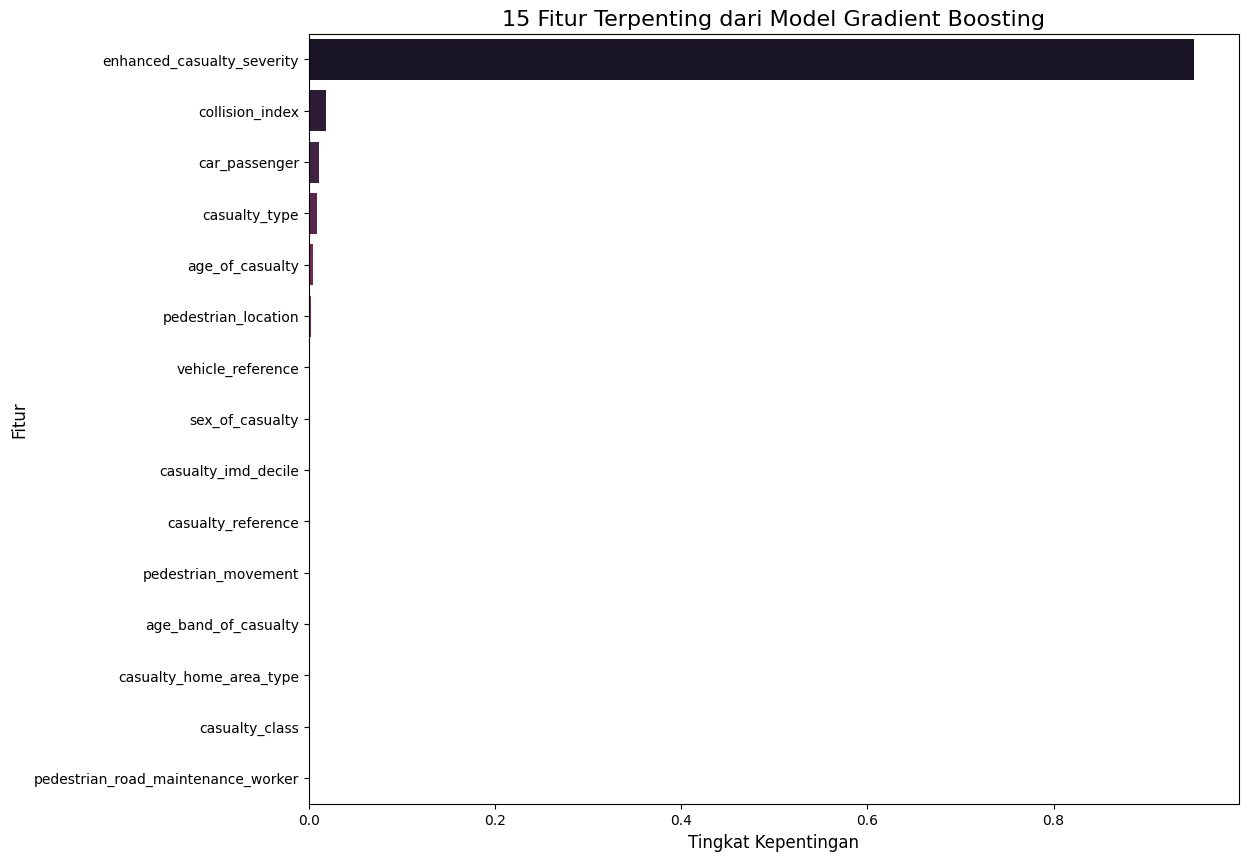

In [ ]:
# SEL BARU 7: ANALISIS PENTINGNYA FITUR (FEATURE IMPORTANCE)

# Menggunakan model Gradient Boosting yang sudah dilatih
importances = best_gb.feature_importances_
feature_names = X.columns

# Membuat DataFrame untuk visualisasi
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Menampilkan 15 fitur teratas
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), palette='rocket')
plt.title('15 Fitur Terpenting dari Model Gradient Boosting', fontsize=16)
plt.xlabel('Tingkat Kepentingan', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.show()